In [1]:
# imports
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from eofs.xarray import Eof
from utils import *

In [2]:
train_files= ['ssp126', 'ssp585', 'historical']

In [3]:
Xtrain, eof_solvers = get_Xtrain(train_files)
train_nan_mask = Xtrain.isna().any(axis=1).values
Xtrain = Xtrain.dropna(axis=0, how='any')

Ytrain = get_Ytrain(train_files)

Xtest = get_Xtest('ssp370', eof_solvers)
test_nan_mask = Xtest.isna().any(axis=1).values
Xtest = Xtest.dropna(axis=0, how='any')

Ytest = get_Ytest('ssp370')

In [4]:
ssp126_nyear = 86
ssp585_nyear = 86

# Emission

## CO2

In [5]:
ssp126_co2 = Xtrain.iloc[:ssp126_nyear, :1]
ssp585_co2 = Xtrain.iloc[ssp126_nyear:ssp126_nyear+ssp585_nyear, :1]
historical_co2 = Xtrain.iloc[ssp126_nyear+ssp585_nyear:, :1]
ssp126_co2.index = np.arange(2015, 2101)
ssp585_co2.index = np.arange(2015, 2101)
historical_co2.index = np.arange(1850, 2015)

In [6]:
co2 = pd.concat([ssp126_co2, ssp585_co2, historical_co2], axis=1)
co2.columns = ['ssp126', 'ssp585', 'historical']

<Axes: >

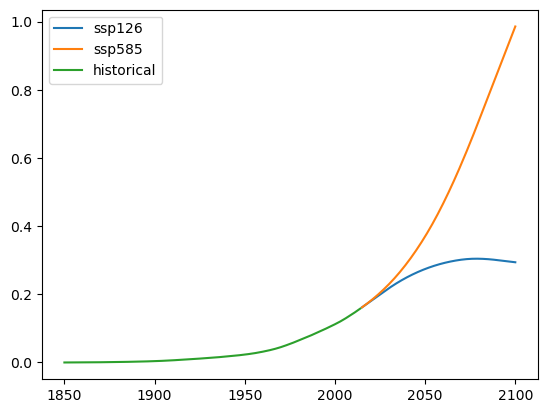

In [7]:
co2.plot()

## CH4

In [8]:
ssp126_ch4 = Xtrain.iloc[:ssp126_nyear, 1:2]
ssp585_ch4 = Xtrain.iloc[ssp126_nyear:ssp126_nyear+ssp585_nyear, 1:2]
historical_ch4 = Xtrain.iloc[ssp126_nyear+ssp585_nyear:, 1:2]
ssp126_ch4.index = np.arange(2015, 2101)
ssp585_ch4.index = np.arange(2015, 2101)
historical_ch4.index = np.arange(1850, 2015)

In [9]:
ch4 = pd.concat([ssp126_ch4, ssp585_ch4, historical_ch4], axis=1)
ch4.columns = ['ssp126', 'ssp585', 'historical']

<Axes: >

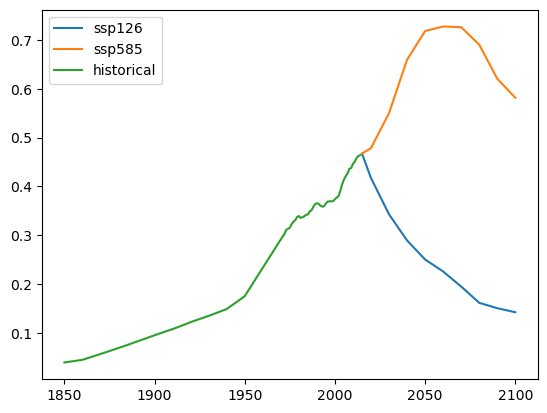

In [10]:
ch4.plot()

## SO2

In [11]:
def get_Xtrain_no_pca(data_sets, n_eofs=5):        
    if isinstance(data_sets, str):
        data_sets = [data_sets]
    X = xr.concat([xr.open_dataset(input_dir + f"inputs_{file}.nc") for file in data_sets], dim='time')
    X = X.assign_coords(time=np.arange(len(X.time)))
    return X

Xtrain_no_pca = get_Xtrain_no_pca(train_files)

In [12]:
# mean
mean_so2 = Xtrain_no_pca['SO2'].mean(['latitude', 'longitude']).to_dataframe()
ssp126_so2 = mean_so2.iloc[:ssp126_nyear]
ssp585_so2 = mean_so2.iloc[ssp126_nyear:ssp126_nyear+ssp585_nyear]
historical_so2 = mean_so2.iloc[ssp126_nyear+ssp585_nyear:]
ssp126_so2.index = np.arange(2015, 2101)
ssp585_so2.index = np.arange(2015, 2101)
historical_so2.index = np.arange(1850, 2015)

In [13]:
mean_so2 = pd.concat([ssp126_so2, ssp585_so2, historical_so2], axis=1)
mean_so2.columns = ['ssp126', 'ssp585', 'historical']

<Axes: >

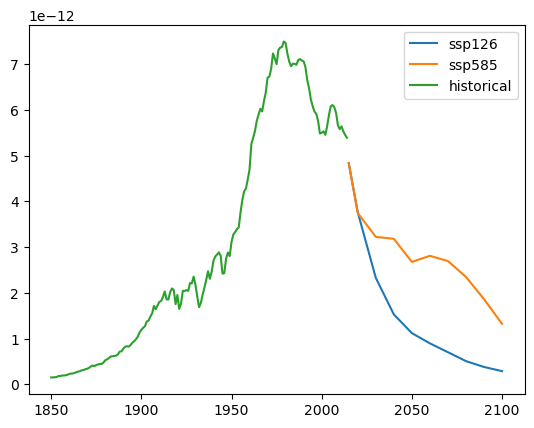

In [14]:
mean_so2.plot()

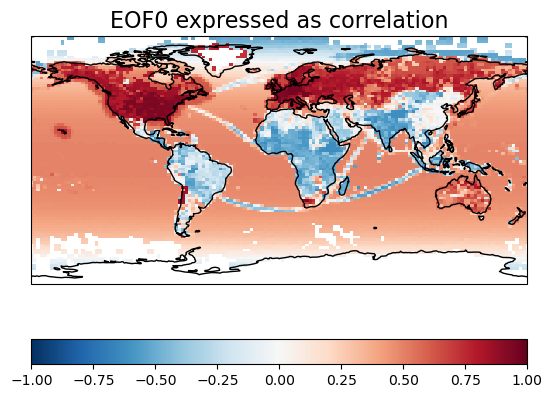

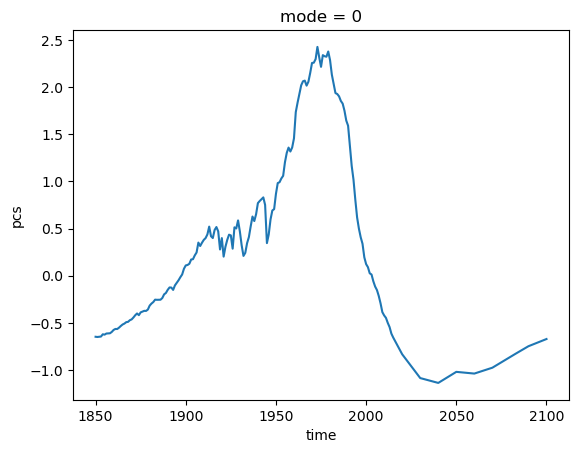

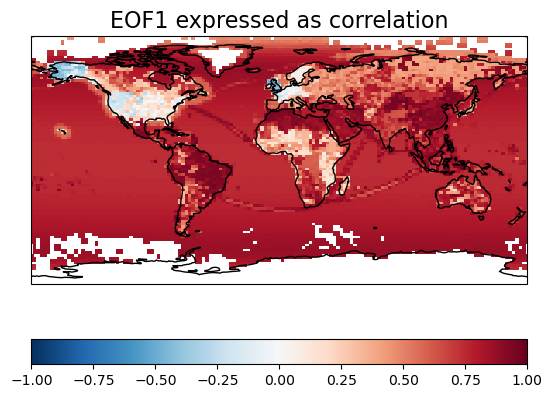

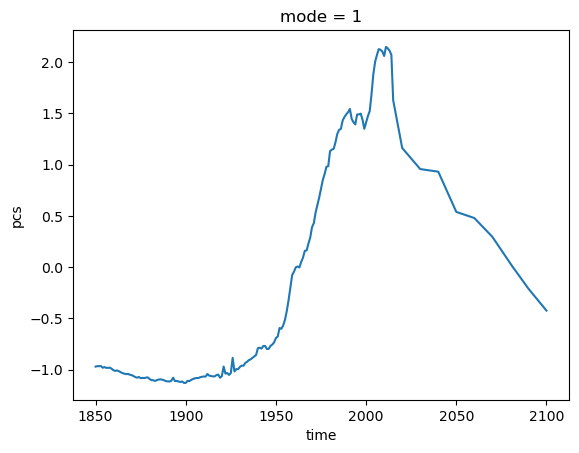

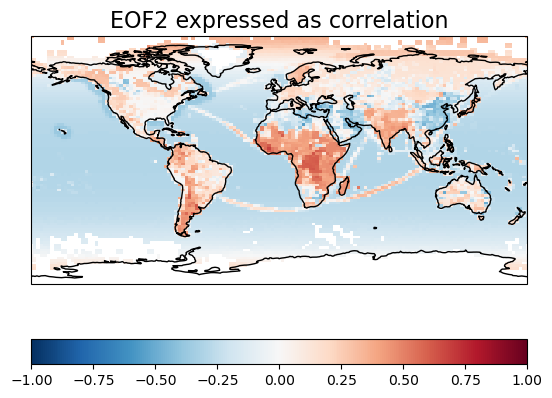

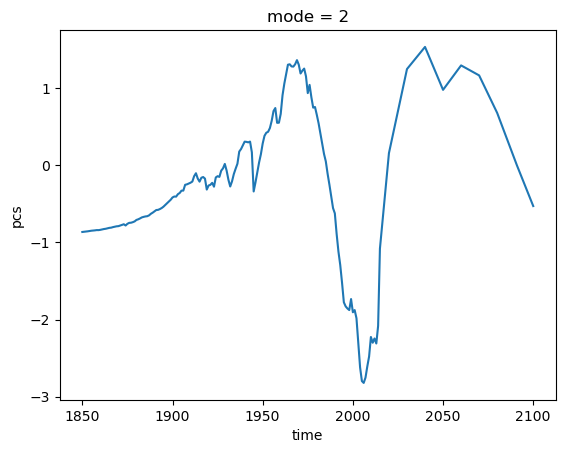

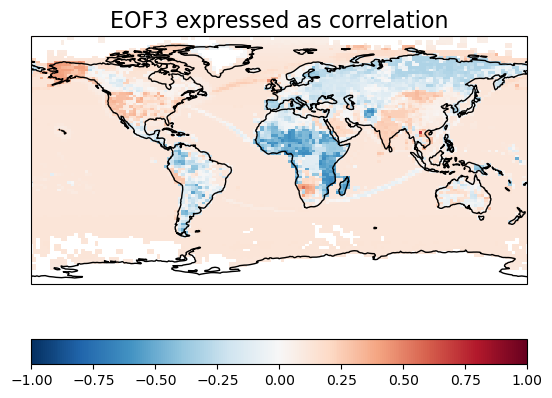

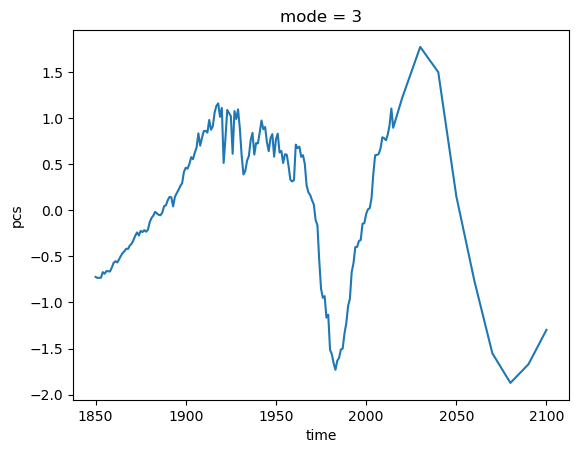

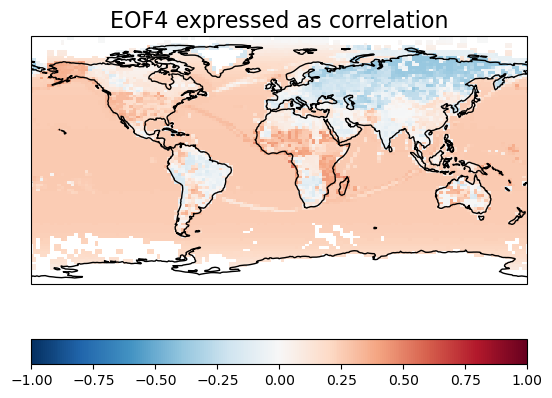

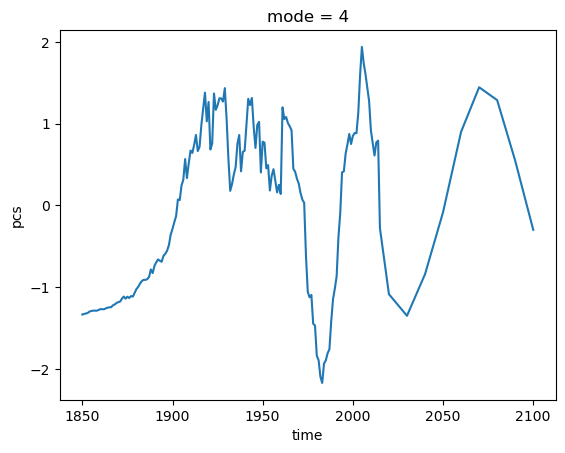

In [15]:
# Create an EOF solver to do the EOF analysis. Square-root of cosine of
# latitude weights are applied before the computation of EOFs.
hist_585 = get_Xtrain_no_pca(['historical', 'ssp585'])
hist_585 = hist_585.assign_coords(time=np.arange(1850, 2101))
so2_solver = Eof(hist_585['SO2'])

# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
so2_eofs = so2_solver.eofsAsCorrelation(neofs=5)
so2_pcs = so2_solver.pcs(npcs=5, pcscaling=1)

for (mode, eof), (_, pc) in zip(so2_eofs.groupby('mode'), so2_pcs.groupby('mode')):
    # Plot the leading EOF expressed as correlation in the Pacific domain.
    clevs = np.linspace(-1, 1, 11)
    eof = eof.sel(mode=mode)
    eof.plot.pcolormesh(subplot_kws={'projection': ccrs.PlateCarree()},
                        cbar_kwargs={'label': '', 'orientation':'horizontal'}, vmin=-1.)
    plt.gca().coastlines()
    plt.gca().set_title(f"EOF{mode} expressed as correlation", fontsize=16)
    plt.show()
    pc.plot()
    plt.show()



## BC

In [16]:
# mean
mean_bc = Xtrain_no_pca['BC'].mean(['latitude', 'longitude']).to_dataframe()
ssp126_bc = mean_bc.iloc[:ssp126_nyear]
ssp585_bc = mean_bc.iloc[ssp126_nyear:ssp126_nyear+ssp585_nyear]
historical_bc = mean_bc.iloc[ssp126_nyear+ssp585_nyear:]
ssp126_bc.index = np.arange(2015, 2101)
ssp585_bc.index = np.arange(2015, 2101)
historical_bc.index = np.arange(1850, 2015)

In [17]:
mean_bc = pd.concat([ssp126_bc, ssp585_bc, historical_bc], axis=1)
mean_bc.columns = ['ssp126', 'ssp585', 'historical']

<Axes: >

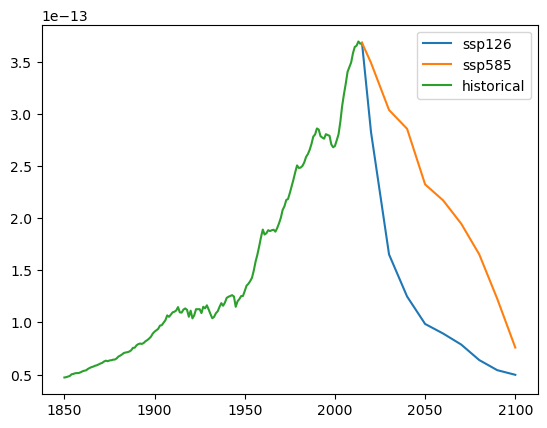

In [18]:
mean_bc.plot()

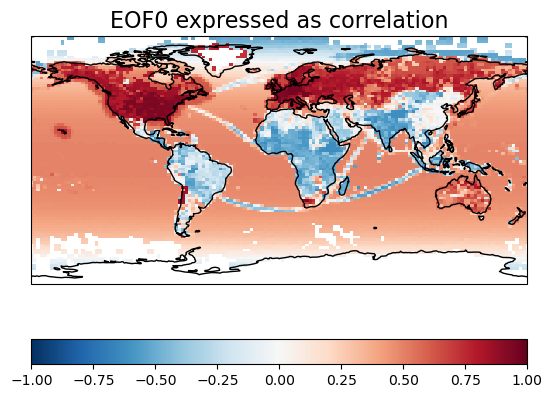

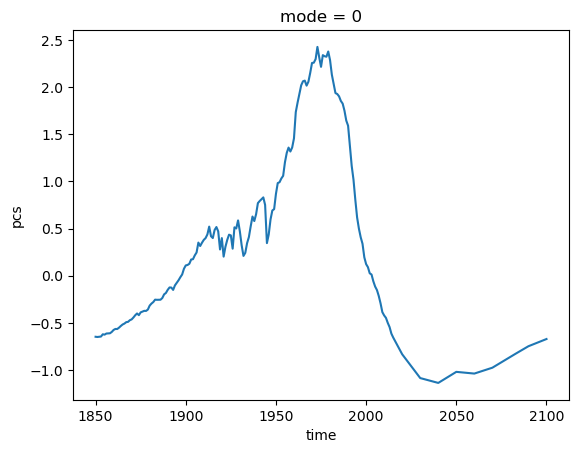

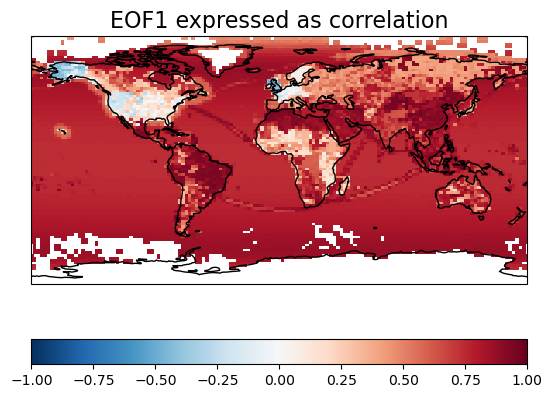

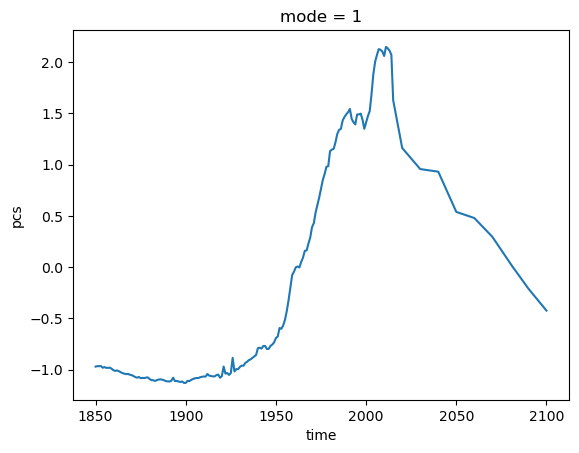

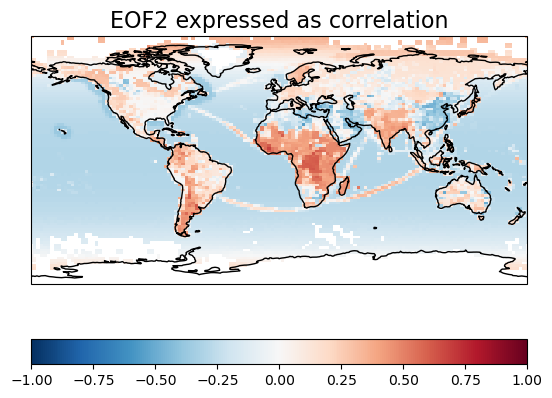

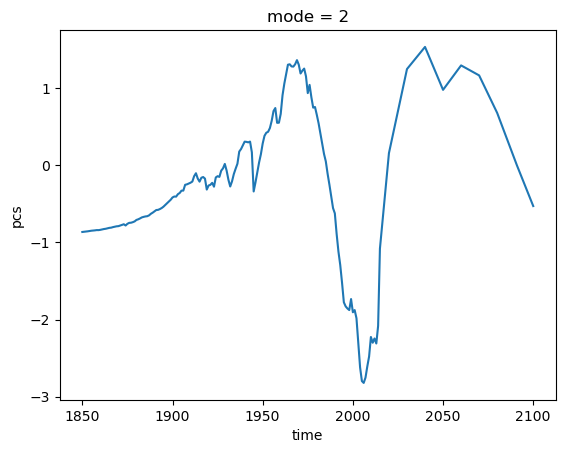

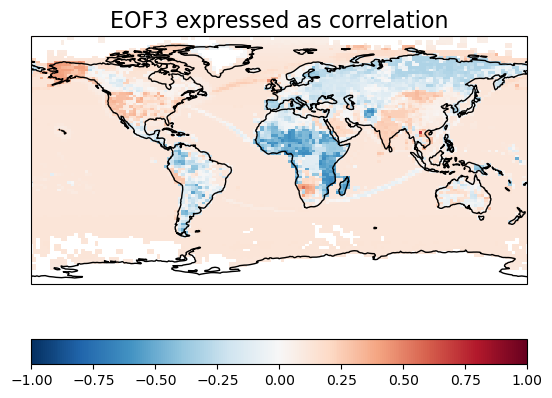

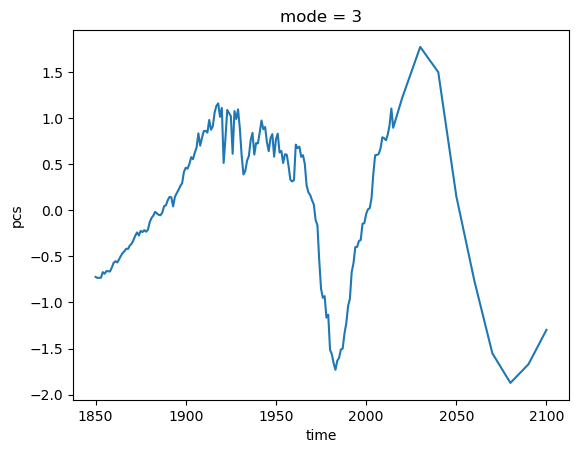

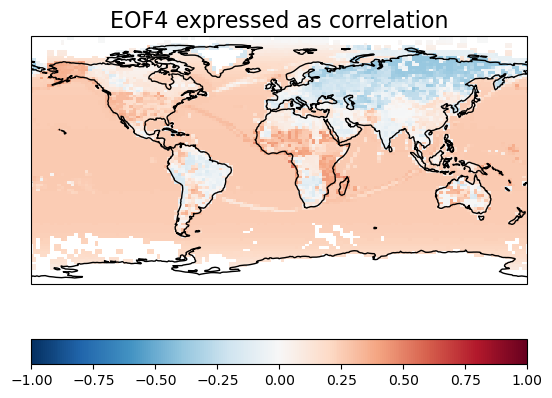

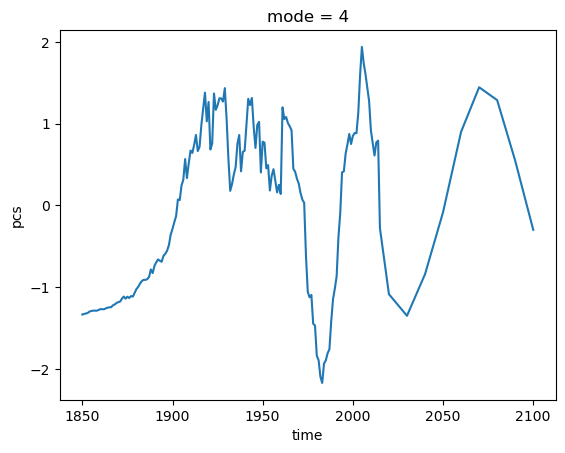

In [19]:
# Create an EOF solver to do the EOF analysis. Square-root of cosine of
# latitude weights are applied before the computation of EOFs.
hist_585 = get_Xtrain_no_pca(['historical', 'ssp585'])
hist_585 = hist_585.assign_coords(time=np.arange(1850, 2101))
bc_solver = Eof(hist_585['BC'])

# Retrieve the leading EOF, expressed as the correlation between the leading
# PC time series and the input SST anomalies at each grid point, and the
# leading PC time series itself.
bc_eofs = so2_solver.eofsAsCorrelation(neofs=5)
bc_pcs = so2_solver.pcs(npcs=5, pcscaling=1)

for (mode, eof), (_, pc) in zip(so2_eofs.groupby('mode'), bc_pcs.groupby('mode')):
    # Plot the leading EOF expressed as correlation in the Pacific domain.
    clevs = np.linspace(-1, 1, 11)
    eof = eof.sel(mode=mode)
    eof.plot.pcolormesh(subplot_kws={'projection': ccrs.PlateCarree()},
                        cbar_kwargs={'label': '', 'orientation':'horizontal'}, vmin=-1.)
    plt.gca().coastlines()
    plt.gca().set_title(f"EOF{mode} expressed as correlation", fontsize=16)
    plt.show()
    pc.plot()
    plt.show()



# Crop Yield

In [20]:
ssp126_yield = Ytrain.isel(time=slice(0, ssp126_nyear))
ssp126_yield_global_sum = ssp126_yield.sum(['lat', 'lon'])

ssp585_yield = Ytrain.isel(time=slice(ssp126_nyear, ssp126_nyear+ssp585_nyear))
ssp585_yield_global_sum = ssp585_yield.sum(['lat', 'lon'])

historical_yield = Ytrain.isel(time=slice(ssp126_nyear+ssp585_nyear, None))
historical_yield_global_sum = historical_yield.sum(['lat', 'lon'])

In [21]:
ssp126_yield_df = ssp126_yield_global_sum.to_dataframe()
ssp126_yield_df.index = np.arange(2015, 2101)

ssp585_yield_df = ssp585_yield_global_sum.to_dataframe()
ssp585_yield_df.index = np.arange(2015, 2101)

historical_yield_df = historical_yield_global_sum.to_dataframe()
historical_yield_df.index = np.arange(1850, 2015)

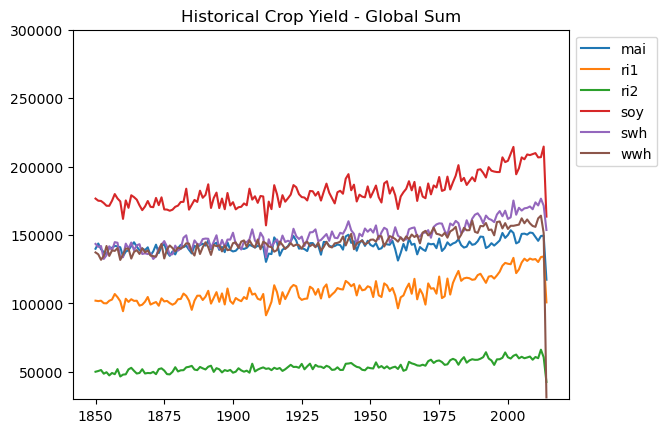

In [22]:
fig = plt.figure()
ax = plt.subplot(111)
historical_yield_df.plot(ax=ax)
ax.legend(bbox_to_anchor=(1, 1))
plt.title('Historical Crop Yield - Global Sum')
plt.ylim(30000, 300000)
plt.show()

**Note**: The historical simulation output from LPJml exhibits some anomalies.

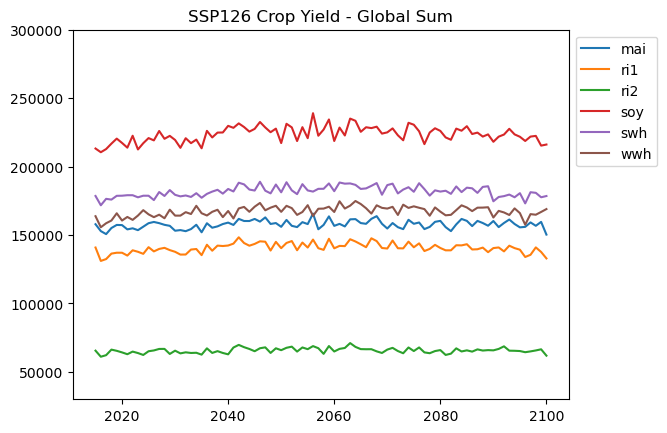

In [23]:
fig = plt.figure()
ax = plt.subplot(111)
ssp126_yield_df.plot(ax=ax)
ax.legend(bbox_to_anchor=(1, 1))
plt.title('SSP126 Crop Yield - Global Sum')
plt.ylim(30000, 300000)
plt.show()

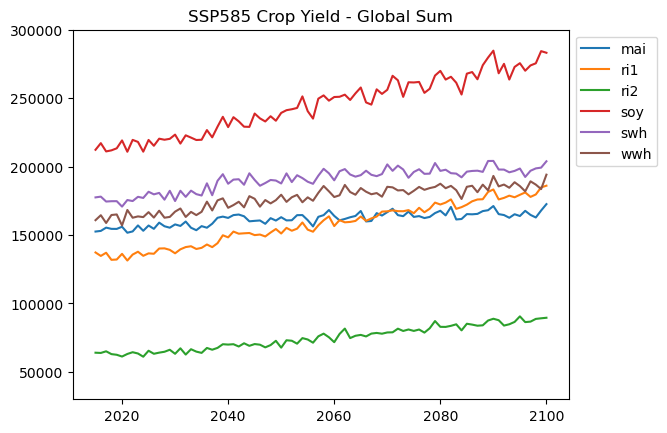

In [24]:
fig = plt.figure()
ax = plt.subplot(111)
ssp585_yield_df.plot(ax=ax)
ax.legend(bbox_to_anchor=(1, 1))
plt.title('SSP585 Crop Yield - Global Sum')
plt.ylim(30000, 300000)
plt.show()